In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dataset/mnist_train.csv')
df.sample()
df['label'].value_counts()

,count
label,
1,4684
7,4401
3,4351
9,4188
2,4177
6,4137
0,4132
4,4072
8,4063


In [28]:
df.shape

(42000, 785)

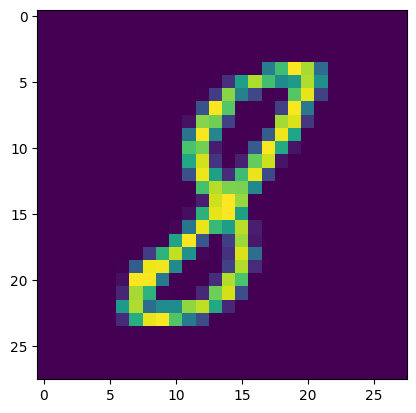

In [29]:
plt.imshow(df.iloc[37711,1:].values.reshape(28,28))

In [30]:
X= df.iloc[:,1:]
y=df.iloc[:,0]

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=5,test_size=0.2)

In [31]:
X_train.isnull().sum().sum()

np.int64(0)

In [32]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

In [33]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [34]:
y_pred = knn.predict(X_test)

In [35]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9648809523809524

Using PCA

In [92]:
X= df.iloc[:,1:]
y=df.iloc[:,0]

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=5,test_size=0.2)

In [93]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [94]:
from sklearn.decomposition import PCA
pca = PCA(n_components=5)
# taking 5 dimension, not dont worry about accuracy

In [95]:
X_train_scaled = pca.fit_transform(X_train_scaled)
X_test_scaled = pca.transform(X_test_scaled)

In [96]:
X_train_scaled.shape

(33600, 5)

In [97]:
knn = KNeighborsClassifier()
knn.fit(X_train_scaled,y_train)

KNeighborsClassifier()

In [98]:
y_pred = knn.predict(X_test_scaled)
y_pred

array([5, 8, 1, ..., 8, 3, 0])

In [99]:
accuracy_score(y_pred,y_test)

0.7309523809523809

In [100]:
pca.explained_variance_
#eigenvalues

array([40.6342314 , 29.08929832, 26.69455678, 20.82517206, 18.03378216])

In [101]:
pca.explained_variance_ratio_
#vaiance percentage explained by the data

array([0.0578818 , 0.04143651, 0.0380253 , 0.0296646 , 0.02568838])

In [102]:
pca.components_  #eigenvectors

array([[-0., -0., -0., ..., -0., -0., -0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.]])

In [103]:
pca.components_.shape

(5, 784)

In [105]:
#finding optimum number


In [110]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.decomposition import PCA
pca = PCA(n_components=None)
X_train_trf = pca.fit_transform(X_train_scaled)
X_test_trf = pca.transform(X_test_scaled)

In [112]:
pca.explained_variance_ratio_.shape

(784,)

In [113]:
pca.components_.shape

(784, 784)

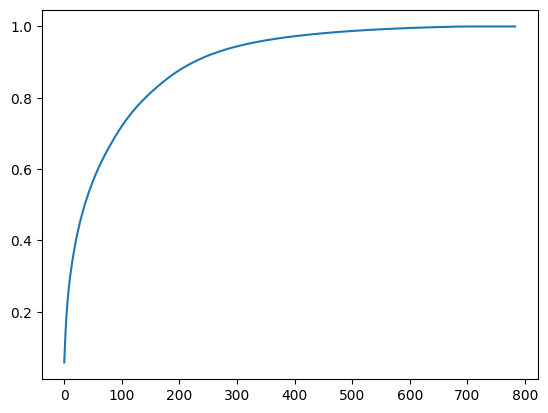

In [114]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))

In [115]:
# we have to get atleast 90%
# here, 250 to 400